# ResNet50 + LSTM Deepfake Detection
Train a ResNet50 + LSTM model on extracted frames and save the trained model.

In [1]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
print('Libraries loaded')

Libraries loaded


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [3]:
real_path = '../frames/real_frames'
fake_path = '../frames/fake_frames'

In [4]:
class DeepfakeDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None):
        self.images = []
        self.labels = []
        self.transform = transform
        for img in os.listdir(real_dir):
            self.images.append(os.path.join(real_dir, img))
            self.labels.append(0)
        for img in os.listdir(fake_dir):
            self.images.append(os.path.join(fake_dir, img))
            self.labels.append(1)
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img = cv2.imread(self.images[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx])
        return img, label

In [5]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [6]:
dataset = DeepfakeDataset(real_path, fake_path, transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
print('Total images:', len(dataset))

Total images: 68491


In [7]:
class ResNetLSTM(nn.Module):
    def __init__(self):
        super(ResNetLSTM, self).__init__()
        self.resnet = models.resnet50(weights='DEFAULT')
        self.resnet.fc = nn.Identity()
        self.lstm = nn.LSTM(input_size=2048, hidden_size=256, num_layers=1, batch_first=True)
        self.fc = nn.Linear(256,2)
    def forward(self,x):
        features = self.resnet(x)
        features = features.unsqueeze(1)
        lstm_out,_ = self.lstm(features)
        out = self.fc(lstm_out[:,-1,:])
        return out

In [8]:
model = ResNetLSTM().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
print('Model ready')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\GANESH_05/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:36<00:00, 2.84MB/s]


Model ready


In [9]:
epochs = 5
model.train()
for epoch in range(epochs):
    running_loss = 0
    correct = 0
    total = 0
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    print(f'Epoch [{epoch+1}/{epochs}] Loss:{epoch_loss:.4f} Accuracy:{epoch_acc:.2f}%')

Epoch [1/5] Loss:0.1940 Accuracy:92.88%
Epoch [2/5] Loss:0.1111 Accuracy:95.87%
Epoch [3/5] Loss:0.0749 Accuracy:97.13%
Epoch [4/5] Loss:0.0564 Accuracy:97.84%
Epoch [5/5] Loss:0.0442 Accuracy:98.30%


In [10]:
os.makedirs('../models', exist_ok=True)
torch.save(model.state_dict(),'../models/resnet_lstm_deepfake.pth')
print('Model saved to models/resnet_lstm_deepfake.pth')

Model saved to models/resnet_lstm_deepfake.pth


In [20]:
import torch.nn.functional as F

def generate_gradcam(model, image, target_class):

    model.train()

    image = image.unsqueeze(0).to(device)
    image.requires_grad = True

    features = model.resnet(image)
    features.retain_grad()

    features_seq = features.unsqueeze(1)
    lstm_out, _ = model.lstm(features_seq)

    output = model.fc(lstm_out[:, -1, :])

    loss = output[0, target_class]

    model.zero_grad()
    loss.backward()

    gradients = features.grad
    activations = features

    weights = torch.mean(gradients, dim=1, keepdim=True)

    cam = torch.sum(weights * activations, dim=1)

    cam = torch.relu(cam)

    cam = cam.detach().cpu().numpy()

    # FIX SHAPE
    if len(cam.shape) == 0:
        cam = np.zeros((224,224))

    cam = cv2.resize(cam, (224,224))

    # normalize
    cam = cam / (cam.max() + 1e-8)

    return cam

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

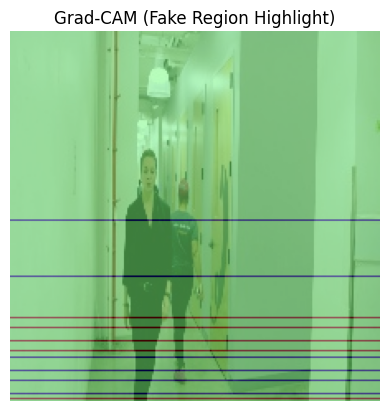

In [21]:
import matplotlib.pyplot as plt

img_name = os.listdir("../frames/fake_frames")[0]

img_path = "../frames/fake_frames/" + img_name

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_img = transform(img_rgb)

cam = generate_gradcam(model, input_img, target_class=1)

plt.imshow(img_rgb)
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.title("Grad-CAM (Fake Region Highlight)")
plt.axis("off")